# Neural Network Hyperparameter Tuning & Optimization

This notebook covers:
1. Hyperparameter search (learning rate, dropout, hidden dims, batch size)
2. 2. Threshold optimization using precision-recall curves
   3. 3. Monte Carlo Dropout for uncertainty quantificationBuilding on the baseline MLP from `nn_baseline_v2.ipynb`.

In [63]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix, roc_auc_score,precision_recall_curve,average_precision_score,roc_curve,f1_score
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## Load Data

In [10]:
df = pd.read_parquet('../../../data/processed/engineered_features_nn.parquet')

In [11]:
if 'gsr_count' in df.columns:
    df = df.drop(columns=['gsr_count'])
    print('Dropped gsr_count')

meta_cols = ['stub_id', 'particle_id', 'label', 'target', 'final_class']
feature_cols = [c for c in df.columns if c not in meta_cols]

print(f'Shape: {df.shape}')
print(f'Features: {len(feature_cols)}')
print(f'Label distribution:\n{df["label"].value_counts()}')

Dropped gsr_count
Shape: (2294985, 61)
Features: 56
Label distribution:
label
Non_GSR    1216039
GSR        1078946
Name: count, dtype: int64


## Group-Aware Train/Val/Test Split

In [14]:
X = df[feature_cols].values.astype(np.float32)
y = df['target'].values.astype(np.float32)
groups = df['stub_id'].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, y, groups))
X_trainval, X_test_raw = X[trainval_idx], X[test_idx]
y_trainval, y_test = y[trainval_idx], y[test_idx]
groups_trainval = groups[trainval_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx_rel, val_idx_rel = next(gss2.split(X_trainval, y_trainval, groups_trainval))
X_train_raw = X_trainval[train_idx_rel]
X_val_raw = X_trainval[val_idx_rel]
y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]
groups_train = groups_trainval[train_idx_rel]

In [17]:
train_stubs = set(groups_train)
val_stubs = set(groups_trainval[val_idx_rel])
test_stubs = set(groups[test_idx])

assert len(train_stubs & val_stubs) == 0
assert len(train_stubs & test_stubs) == 0
assert len(val_stubs & test_stubs) == 0
print(f'Train: {len(X_train_raw):,} ({y_train.mean():.1%} GSR)')
print(f'Val: {len(X_val_raw):,} ({y_val.mean():.1%} GSR)')
print(f'Test: {len(X_test_raw):,} ({y_test.mean():.1%} GSR)')
print('No stub overlap confirmed.')

Train: 1,444,147 (49.7% GSR)
Val: 407,614 (37.1% GSR)
Test: 443,224 (47.4% GSR)
No stub overlap confirmed.


In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

## MLP Architecture (Tunable)

In [22]:
class TunableMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, n_layers=2, dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for _ in range(n_layers):
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## Hyperparameter Search

Search over:
- Learning rate: [1e-4, 5e-4, 1e-3]
- Dropout: [0.2, 0.3, 0.4]
- Hidden dim: [64, 128, 256]
- Number of layers: [2, 3]

Using validation loss as the selection criterion. Early stopping with patience=5.

In [23]:
def train_model(X_tr, y_tr, X_vl, y_vl, input_dim,
                hidden_dim=128, n_layers=2, dropout=0.3,
                lr=1e-3, batch_size=4096, max_epochs=30, patience=5):
    """Train MLP with given hyperparameters, return best model state and metrics."""
    model = TunableMLP(input_dim, hidden_dim, n_layers, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    train_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                              torch.tensor(y_tr, dtype=torch.float32))
    val_ds = TensorDataset(torch.tensor(X_vl, dtype=torch.float32),
                            torch.tensor(y_vl, dtype=torch.float32))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss, n_batches = 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb).squeeze()
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)

        model.eval()
        val_loss, n_val = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb).squeeze(), yb).item()
                n_val += 1
        val_losses.append(val_loss / n_val)

        if val_losses[-1] < best_val_loss:
            best_val_loss = val_losses[-1]
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss, train_losses, val_losses

In [28]:
param_grid = [
    {'lr': 1e-3, 'dropout': 0.3, 'hidden_dim': 128, 'n_layers': 2},  #baseline
    {'lr': 1e-3, 'dropout': 0.2, 'hidden_dim': 128, 'n_layers': 2},  #less dropout
    {'lr': 1e-3, 'dropout': 0.4, 'hidden_dim': 128, 'n_layers': 2},  #more dropout
    {'lr': 5e-4, 'dropout': 0.3, 'hidden_dim': 128, 'n_layers': 2},  #slower lr
    {'lr': 1e-3, 'dropout': 0.3, 'hidden_dim': 256, 'n_layers': 2},  #wider
    {'lr': 1e-3, 'dropout': 0.3, 'hidden_dim': 128, 'n_layers': 3},  #deeper
    {'lr': 5e-4, 'dropout': 0.3, 'hidden_dim': 256, 'n_layers': 3},  #wider+deeper+slower
]

print(f'Total configurations: {len(param_grid)}')

Total configurations: 7


In [30]:
results = []
for i, params in enumerate(param_grid):
    print(f'\n[{i+1}/{len(param_grid)}] lr={params["lr"]}, dropout={params["dropout"]}, '
          f'hidden={params["hidden_dim"]}, layers={params["n_layers"]}')

    model, best_val_loss, t_losses, v_losses = train_model(
        X_train, y_train, X_val, y_val,
        input_dim=len(feature_cols),
        max_epochs=15,
        **params
    )

    model.eval()
    with torch.no_grad():
        test_logits = model(torch.tensor(X_test, dtype=torch.float32).to(device)).squeeze().cpu().numpy()
    test_probs = 1 / (1 + np.exp(-test_logits))
    test_preds = (test_probs >= 0.5).astype(int)
    cm = confusion_matrix(y_test, test_preds)
    roc = roc_auc_score(y_test, test_probs)
    fpr = cm[0,1] / cm[0].sum()

    results.append({
        **params,
        'val_loss': best_val_loss,
        'test_roc_auc': roc,
        'test_fpr': fpr,
        'test_accuracy': (test_preds == y_test).mean(),
        'epochs': len(t_losses)
    })
    print(f'val_loss={best_val_loss:.6f}, ROC-AUC={roc:.4f}, FPR={fpr:.4f}, acc={(test_preds == y_test).mean():.4f}')

results_df = pd.DataFrame(results).sort_values('val_loss')


[1/7] lr=0.001, dropout=0.3, hidden=128, layers=2
val_loss=0.001815, ROC-AUC=1.0000, FPR=0.0009, acc=0.9994

[2/7] lr=0.001, dropout=0.2, hidden=128, layers=2
val_loss=0.001934, ROC-AUC=1.0000, FPR=0.0009, acc=0.9993

[3/7] lr=0.001, dropout=0.4, hidden=128, layers=2
val_loss=0.001907, ROC-AUC=1.0000, FPR=0.0010, acc=0.9993

[4/7] lr=0.0005, dropout=0.3, hidden=128, layers=2
val_loss=0.002211, ROC-AUC=1.0000, FPR=0.0012, acc=0.9993

[5/7] lr=0.001, dropout=0.3, hidden=256, layers=2
val_loss=0.001809, ROC-AUC=1.0000, FPR=0.0010, acc=0.9993

[6/7] lr=0.001, dropout=0.3, hidden=128, layers=3
val_loss=0.001917, ROC-AUC=1.0000, FPR=0.0009, acc=0.9993

[7/7] lr=0.0005, dropout=0.3, hidden=256, layers=3
val_loss=0.001838, ROC-AUC=1.0000, FPR=0.0008, acc=0.9993


In [33]:
print('Top 3 Configurations:')
print(results_df.head(3).to_string(index=False))


Top 3 Configurations:
    lr  dropout  hidden_dim  n_layers  val_loss  test_roc_auc  test_fpr  test_accuracy  epochs
0.0010      0.3         256         2  0.001809      0.999994  0.000986       0.999314      15
0.0010      0.3         128         2  0.001815      0.999993  0.000900       0.999359      15
0.0005      0.3         256         3  0.001838      0.999994  0.000793       0.999332      15


## Retrain Best Model

In [36]:
best_config = results_df.iloc[0]
print(f'Best config: {best_config.to_dict()}')

best_model, best_val_loss, train_losses, val_losses = train_model(X_train, y_train, X_val, y_val,input_dim=len(feature_cols),lr=best_config['lr'],dropout=best_config['dropout'],hidden_dim=int(best_config['hidden_dim']),n_layers=int(best_config['n_layers']),max_epochs=20,patience=5)
print(f'Best val loss: {best_val_loss:.6f}')

Best config: {'lr': 0.001, 'dropout': 0.3, 'hidden_dim': 256.0, 'n_layers': 2.0, 'val_loss': 0.0018094819435827958, 'test_roc_auc': 0.9999937746566628, 'test_fpr': 0.0009859607759082627, 'test_accuracy': 0.999314116564085, 'epochs': 15.0}
Best val loss: 0.001809


## Training vs Validation Loss Curve

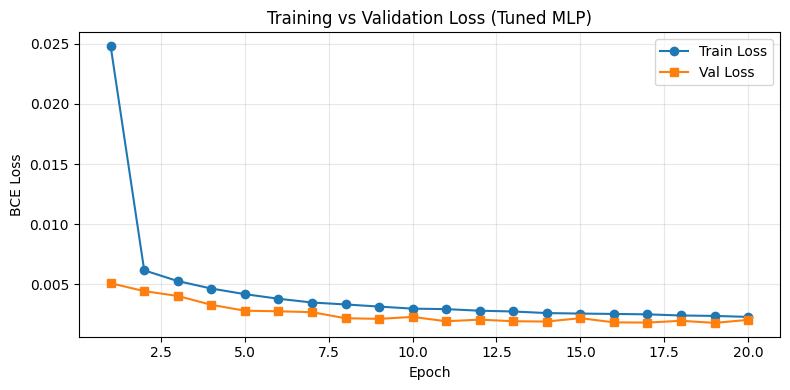

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', marker='o')
ax.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss', marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Training vs Validation Loss (Tuned MLP)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Test Set Evaluation

In [39]:
best_model.eval()
all_logits = []
test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32),torch.tensor(y_test, dtype=torch.float32)),batch_size=4096, shuffle=False)

with torch.no_grad():    
    for xb, _ in test_loader:        
        xb = xb.to(device)        
        all_logits.append(best_model(xb).squeeze().cpu())
        logits_test = torch.cat(all_logits).numpy()
        probs_test = 1 / (1 + np.exp(-logits_test))
        preds_test = (probs_test >= 0.5).astype(int)

In [40]:
print('Test Set Classification Report (threshold=0.5)')
print(classification_report(y_test, preds_test, target_names=['Non_GSR', 'GSR']))

Test Set Classification Report (threshold=0.5)
              precision    recall  f1-score   support

     Non_GSR       1.00      1.00      1.00    233275
         GSR       1.00      1.00      1.00    209949

    accuracy                           1.00    443224
   macro avg       1.00      1.00      1.00    443224
weighted avg       1.00      1.00      1.00    443224



In [42]:
cm = confusion_matrix(y_test, preds_test)
print(f'Confusion Matrix:')
cm

Confusion Matrix:


array([[233118,    157],
       [   127, 209822]])

In [43]:
print(f'TN={cm[0,0]:,}  FP={cm[0,1]:,}')
print(f'FN={cm[1,0]:,}  TP={cm[1,1]:,}')
print(f'\nFPR: {cm[0,1]/cm[0].sum():.4f}')
print(f'FNR: {cm[1,0]/cm[1].sum():.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, probs_test):.4f}')
print(f'PR-AUC: {average_precision_score(y_test, probs_test):.4f}')

TN=233,118  FP=157
FN=127  TP=209,822

FPR: 0.0007
FNR: 0.0006
ROC-AUC: 1.0000
PR-AUC: 1.0000


## ROC and PR Curves

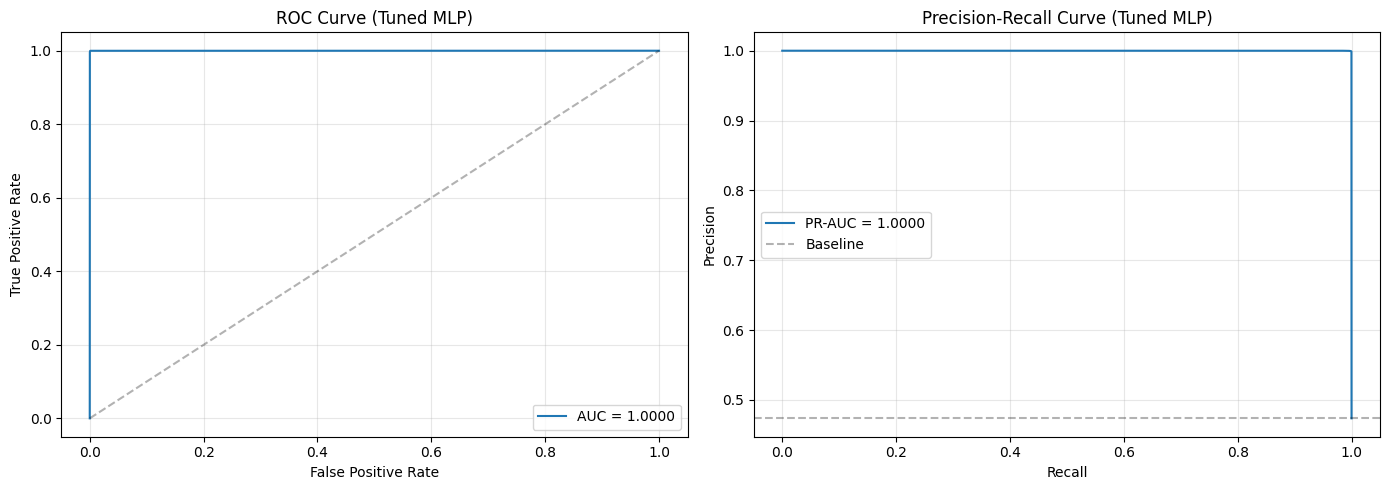

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fpr_curve, tpr_curve, _ = roc_curve(y_test, probs_test)
axes[0].plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc_score(y_test, probs_test):.4f}')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Tuned MLP)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, probs_test)
axes[1].plot(rec, prec, label=f'PR-AUC = {average_precision_score(y_test, probs_test):.4f}')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.3, label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Tuned MLP)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Per-Subclass Performance

In [46]:
test_classes = df['final_class'].values[test_idx]
test_labels = df['label'].values[test_idx]

subclass_results = []
for cls in sorted(np.unique(test_classes)):
    mask = test_classes == cls
    n = mask.sum()
    if n < 10:
        continue
    label = test_labels[mask][0]
    cls_preds = preds_test[mask]
    cls_true = y_test[mask]
    acc = (cls_preds == cls_true).mean()
    if label == 'GSR':
        rate = cls_preds.mean()
        metric_name = 'Recall'
    else:
        rate = 1 - cls_preds.mean()
        metric_name = 'Specificity'
    subclass_results.append({'Class': cls, 'Label': label, 'N': n,
                              'Accuracy': f'{acc:.4f}', metric_name: f'{rate:.4f}'})

print(pd.DataFrame(subclass_results).to_string(index=False))

 Class   Label      N Accuracy Specificity Recall
  BaAl Non_GSR  65221   0.9986      0.9986    NaN
BaCaSi Non_GSR  81503   0.9995      0.9995    NaN
  BaSb     GSR  20708   0.9962         NaN 0.9962
  CuZn Non_GSR  75472   0.9998      0.9998    NaN
GaCuSn Non_GSR    426   1.0000      1.0000    NaN
    Hg Non_GSR    678   0.9956      0.9956    NaN
  PbBa     GSR  48129   0.9990         NaN 0.9990
PbBaSb     GSR 108047   1.0000         NaN 1.0000
  PbSb     GSR  33065   1.0000         NaN 1.0000
TiZnGd Non_GSR   3434   0.9991      0.9991    NaN
  ZnTi Non_GSR   6541   1.0000      1.0000    NaN


## Threshold Optimization

Default 0.5 threshold is not forensically optimal. We use the precision-recall curve to find thresholds that minimize false positives while maintaining acceptable recall. We identify three operating points:
- **High-specificity**: minimize FP for courtroom evidence
- **Balanced**: maximize F1
- **High-sensitivity**: minimize FN for investigative screening

In [47]:
precisions, recalls, thresholds = precision_recall_curve(y_test, probs_test)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]
high_spec_mask = precisions[:-1] >= 0.9999

if high_spec_mask.any():    
    high_spec_idx = np.where(high_spec_mask)[0][np.argmax(recalls[:-1][high_spec_mask])]    
    high_spec_threshold = thresholds[high_spec_idx]
else:    
    high_spec_threshold = 0.99
    
high_sens_mask = recalls[:-1] >= 0.999

if high_sens_mask.any():    
    high_sens_idx = np.where(high_sens_mask)[0][np.argmax(precisions[:-1][high_sens_mask])]    
    high_sens_threshold = thresholds[high_sens_idx]
else:    
    high_sens_threshold = 0.01

print(f'Threshold Analysis:')
print(f'High-specificity threshold: {high_spec_threshold:.4f}')
print(f'Balanced (best F1) threshold: {best_f1_threshold:.4f}')
print(f'High-sensitivity threshold: {high_sens_threshold:.4f}')

for name, thresh in [('High-specificity', high_spec_threshold),('Balanced (F1)', best_f1_threshold),
                     ('High-sensitivity', high_sens_threshold),                      
                     ('Default (0.5)', 0.5)]:    
    preds = (probs_test >= thresh).astype(int)    
    cm_t = confusion_matrix(y_test, preds)    
    fpr_t = cm_t[0,1] / cm_t[0].sum()    
    fnr_t = cm_t[1,0] / cm_t[1].sum()    
    f1_t = f1_score(y_test, preds)    
    print(f'\n{name} (threshold={thresh:.4f}):')    
    print(f'FPR={fpr_t:.6f}, FNR={fnr_t:.6f}, F1={f1_t:.6f}')    
    print(f'TN={cm_t[0,0]:,}  FP={cm_t[0,1]:,}  FN={cm_t[1,0]:,}  TP={cm_t[1,1]:,}')

Threshold Analysis:
High-specificity threshold: 0.9830
Balanced (best F1) threshold: 0.4316
High-sensitivity threshold: 0.6134

High-specificity (threshold=0.9830):
FPR=0.000086, FNR=0.009898, F1=0.994979
TN=233,255  FP=20  FN=2,078  TP=207,871

Balanced (F1) (threshold=0.4316):
FPR=0.000772, FNR=0.000452, F1=0.999345
TN=233,095  FP=180  FN=95  TP=209,854

High-sensitivity (threshold=0.6134):
FPR=0.000557, FNR=0.000991, F1=0.999195
TN=233,145  FP=130  FN=208  TP=209,741

Default (0.5) (threshold=0.5000):
FPR=0.000673, FNR=0.000605, F1=0.999324
TN=233,118  FP=157  FN=127  TP=209,822


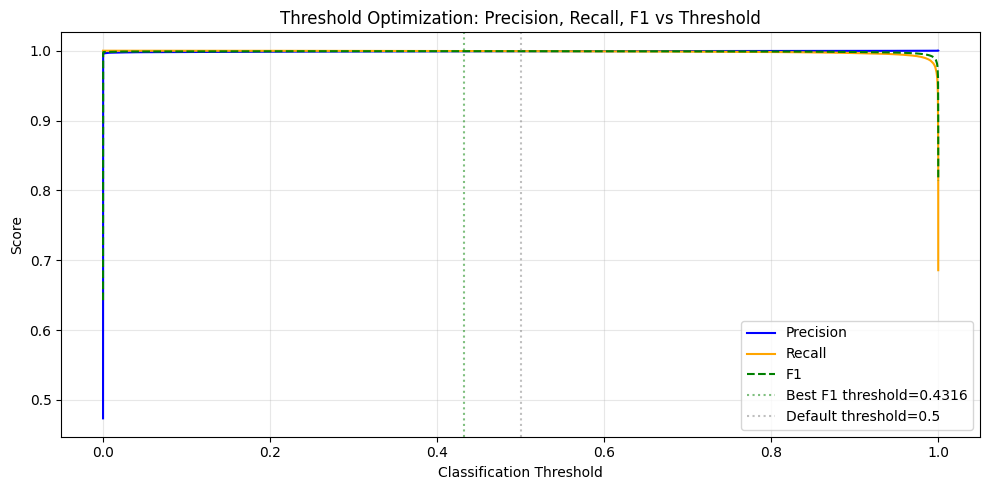

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='blue')
ax.plot(thresholds, recalls[:-1], label='Recall', color='orange')
ax.plot(thresholds, f1_scores, label='F1', color='green', linestyle='--')
ax.axvline(x=best_f1_threshold, color='green', alpha=0.5, linestyle=':',label=f'Best F1 threshold={best_f1_threshold:.4f}')
ax.axvline(x=0.5, color='gray', alpha=0.5, linestyle=':',label='Default threshold=0.5')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimization: Precision, Recall, F1 vs Threshold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Monte Carlo Dropout for Uncertainty Quantification
MC Dropout (Gal & Ghahramani, 2016) runs multiple forward passes with dropout activeat inference time, producing a distribution of predictions per particle.High-variance particles can be flagged for expert review.

In [56]:
def mc_dropout_predict(model, X_tensor, n_forward=50, batch_size=4096):
    """Run n_forward stochastic forward passes with dropout enabled."""
    model.train()  # Keep dropout active
    all_probs = []
    loader = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=False)

    for _ in range(n_forward):
        batch_probs = []
        with torch.no_grad():
            for (xb,) in loader:
                xb = xb.to(device)
                logits = model(xb).squeeze().cpu().numpy()
                probs = 1 / (1 + np.exp(-logits))
                batch_probs.append(probs)
        all_probs.append(np.concatenate(batch_probs))

    all_probs = np.array(all_probs)  # shape: (n_forward, n_samples)
    mean_probs = all_probs.mean(axis=0)
    std_probs = all_probs.std(axis=0)
    return mean_probs, std_probs

In [57]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
mc_mean, mc_std = mc_dropout_predict(best_model, X_test_tensor, n_forward=50)
print(f'MC Dropout Results (50 forward passes):')
print(f'Mean P(GSR) std: {mc_std.mean():.6f}')
print(f'Max P(GSR) std: {mc_std.max():.6f}')
print(f'Particles with std > 0.1: {(mc_std > 0.1).sum():,} ({(mc_std > 0.1).mean():.2%})')
print(f'Particles with std > 0.05: {(mc_std > 0.05).sum():,} ({(mc_std > 0.05).mean():.2%})')

MC Dropout Results (50 forward passes):
Mean P(GSR) std: 0.000762
Max P(GSR) std: 0.375407
Particles with std > 0.1: 1,034 (0.23%)
Particles with std > 0.05: 1,761 (0.40%)


In [58]:
print('\nUncertainty by Subclass:')
print(f'{"Class":>8} {"Label":>8} {"N":>8} {"Mean Std":>10} {"Max Std":>10} {"Std>0.05":>10}')

for cls in sorted(np.unique(test_classes)):    
    mask = test_classes == cls    
    n = mask.sum()    
    
    if n < 10:        
        continue    
    label = test_labels[mask][0]    
    cls_std = mc_std[mask]    
    print(f'{cls:>8} {label:>8} {n:>8} {cls_std.mean():>10.6f} {cls_std.max():>10.6f} 'f'{(cls_std > 0.05).sum():>10,}')


Uncertainty by Subclass:
   Class    Label        N   Mean Std    Max Std   Std>0.05
    BaAl  Non_GSR    65221   0.001165   0.329167        496
  BaCaSi  Non_GSR    81503   0.000180   0.320397         91
    BaSb      GSR    20708   0.005565   0.319757        590
    CuZn  Non_GSR    75472   0.000047   0.375407         20
  GaCuSn  Non_GSR      426   0.000000   0.000000          0
      Hg  Non_GSR      678   0.002588   0.195367         12
    PbBa      GSR    48129   0.002159   0.291646        540
  PbBaSb      GSR   108047   0.000069   0.021860          0
    PbSb      GSR    33065   0.000414   0.060156          2
  TiZnGd  Non_GSR     3434   0.000040   0.115169          1
    ZnTi  Non_GSR     6541   0.000185   0.223264          9


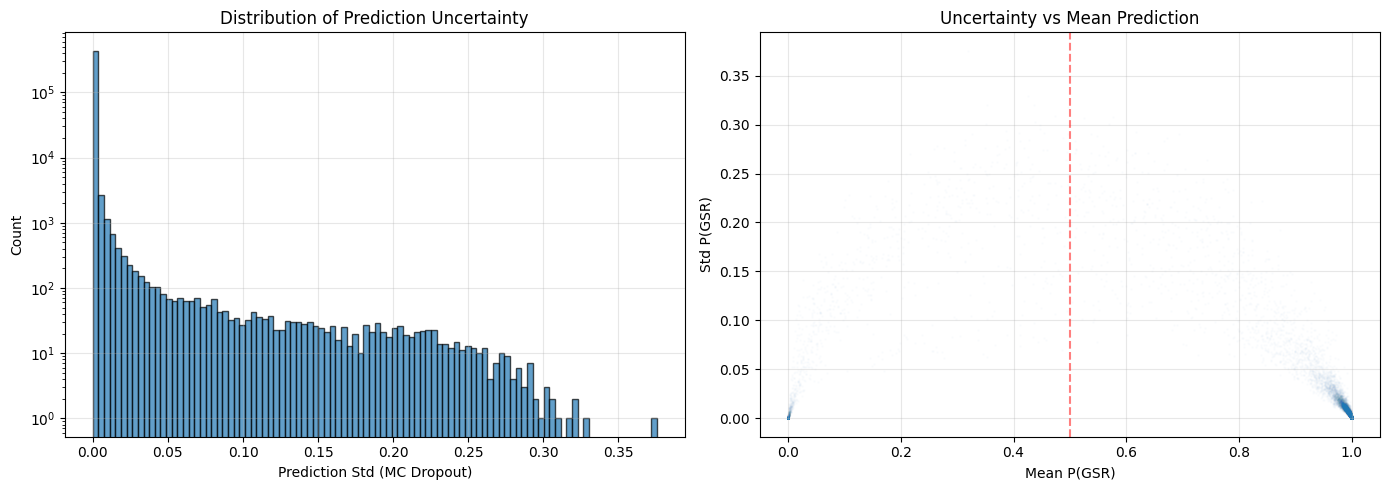

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(mc_std, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Prediction Std (MC Dropout)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Prediction Uncertainty')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)
axes[1].scatter(mc_mean, mc_std, alpha=0.01, s=1)
axes[1].set_xlabel('Mean P(GSR)')
axes[1].set_ylabel('Std P(GSR)')
axes[1].set_title('Uncertainty vs Mean Prediction')
axes[1].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save Tuned Model & ScalerSave for use in NIST validation notebook.

In [60]:
import pickle
import os

artifacts_dir = '../../../artifacts/04_model/neural_network'
os.makedirs(artifacts_dir, exist_ok=True)

torch.save({
    'model_state_dict': best_model.state_dict(),
    'config': {
        'input_dim': len(feature_cols),
        'hidden_dim': int(best_config['hidden_dim']),
        'n_layers': int(best_config['n_layers']),
        'dropout': best_config['dropout'],
    },
    'feature_cols': feature_cols,
    'best_val_loss': best_val_loss,
    'threshold_balanced': best_f1_threshold,
    'threshold_high_spec': high_spec_threshold,
    'threshold_high_sens': high_sens_threshold,
}, os.path.join(artifacts_dir, 'tuned_mlp.pt'))

with open(os.path.join(artifacts_dir, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

print(f'Saved tuned model and scaler to {artifacts_dir}/')

Saved tuned model and scaler to ../../../artifacts/04_model/neural_network/


## Feature impoirtance

In [64]:
def model_score(X_input, y_true):
    with torch.no_grad():
        logits = best_model(torch.tensor(X_input, dtype=torch.float32).to(device)).squeeze().cpu().numpy()
    probs = 1 / (1 + np.exp(-logits))
    return roc_auc_score(y_true, probs)

In [65]:
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_test), size=10000, replace=False)
X_sample = X_test[sample_idx]
y_sample = y_test[sample_idx]

baseline_score = model_score(X_sample, y_sample)
print(f'Baseline ROC-AUC on sample: {baseline_score:.6f}')

Baseline ROC-AUC on sample: 0.999979


In [66]:
#permutation importance: shuffle each feature, measure AUC drop
n_repeats = 5
importance_results = []

for i, col in enumerate(feature_cols):
    drops = []
    for _ in range(n_repeats):
        X_permuted = X_sample.copy()
        X_permuted[:, i] = rng.permutation(X_permuted[:, i])
        permuted_score = model_score(X_permuted, y_sample)
        drops.append(baseline_score - permuted_score)
    importance_results.append({
        'Feature': col,
        'Mean AUC Drop': np.mean(drops),
        'Std': np.std(drops)
    })
    if (i + 1) % 10 == 0:
        print(f'  Processed {i+1}/{len(feature_cols)} features...')

importance_df = pd.DataFrame(importance_results).sort_values('Mean AUC Drop', ascending=False)
print('\nDone!')

  Processed 10/56 features...
  Processed 20/56 features...
  Processed 30/56 features...
  Processed 40/56 features...
  Processed 50/56 features...

Done!


In [67]:
print('Top 15 Features by Permutation Importance (AUC Drop):')
print(importance_df.head(15).to_string(index=False))

Top 15 Features by Permutation Importance (AUC Drop):
                 Feature  Mean AUC Drop      Std
          log_pb_plus_sb       0.081966 0.001664
                  clr_sb       0.000576 0.000050
                  has_ba       0.000187 0.000020
                  clr_pb       0.000113 0.000035
pb_sb_over_non_ba_o_mass       0.000076 0.000022
                  has_pb       0.000065 0.000008
                  clr_al       0.000049 0.000013
                  clr_cu       0.000047 0.000027
                   clr_s       0.000023 0.000010
                  clr_hg       0.000023 0.000009
                  clr_sr       0.000018 0.000003
                   has_s       0.000017 0.000007
                  has_cu       0.000015 0.000020
                  clr_zn       0.000009 0.000007
                  clr_br       0.000007 0.000004


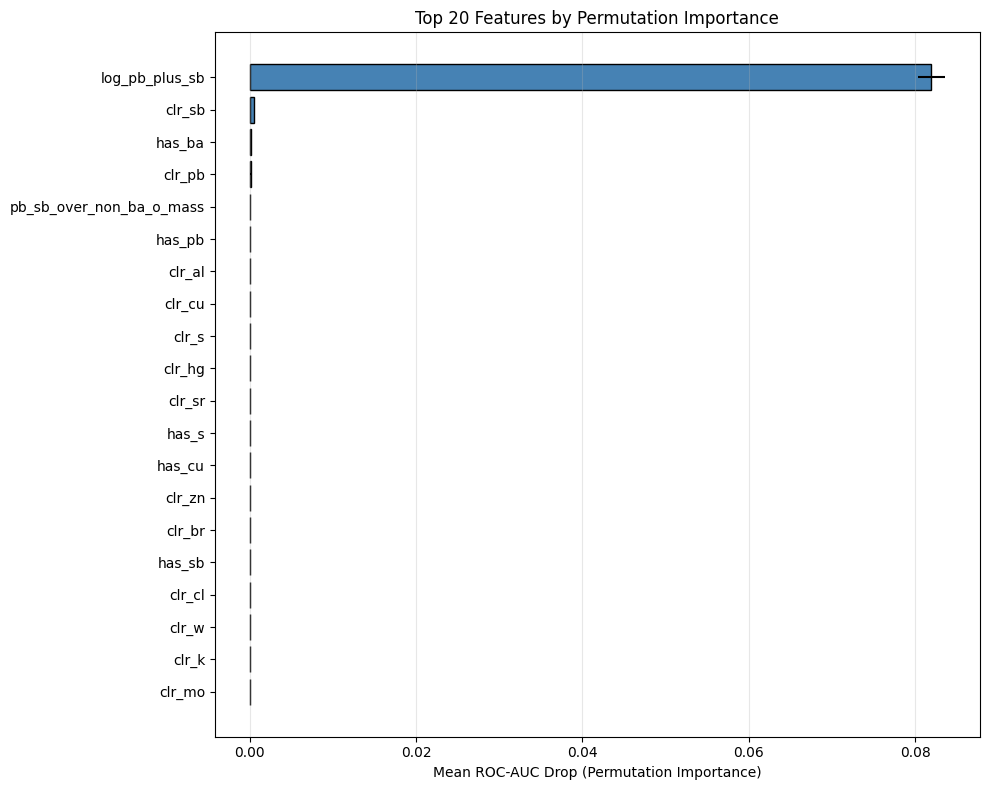

In [68]:
top_n = 20
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(top_n), top_features['Mean AUC Drop'].values, 
        xerr=top_features['Std'].values, color='steelblue', edgecolor='black')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Mean ROC-AUC Drop (Permutation Importance)')
ax.set_title('Top 20 Features by Permutation Importance')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [69]:
importance_df['Type'] = importance_df['Feature'].apply(
    lambda x: 'CLR' if x.startswith('clr_') else 
              ('Presence' if x.startswith('has_') else 'Engineered'))

type_summary = importance_df.groupby('Type')['Mean AUC Drop'].agg(['sum', 'mean', 'max']).sort_values('sum', ascending=False)
print('Feature Importance by Category:')
print(type_summary.to_string())

element_importance = {}
for _, row in importance_df.iterrows():
    feat = row['Feature']
    drop = row['Mean AUC Drop']
    if feat.startswith('clr_'):
        elem = feat[4:]
    elif feat.startswith('has_'):
        elem = feat[4:]
    else:
        elem = feat
    element_importance[elem] = element_importance.get(elem, 0) + max(drop, 0)

elem_df = pd.DataFrame([{'Element': k, 'Combined Importance': v} 
                         for k, v in element_importance.items()]).sort_values('Combined Importance', ascending=False)
print('\nTop 10 Elements by Combined Importance:')
print(elem_df.head(10).to_string(index=False))

Feature Importance by Category:
                 sum      mean       max
Type                                    
Engineered  0.082043  0.041021  0.081966
CLR         0.000807  0.000030  0.000576
Presence    0.000131  0.000005  0.000187

Top 10 Elements by Combined Importance:
                 Element  Combined Importance
          log_pb_plus_sb             0.081966
                      sb             0.000582
                      ba             0.000187
                      pb             0.000178
pb_sb_over_non_ba_o_mass             0.000076
                      cu             0.000062
                      al             0.000049
                       s             0.000040
                      hg             0.000023
                      sr             0.000018


## Summary of Key Results

Traditional hyperparameter tuning doesn't meaningfully improve performance because the model is already near-perfect.

**Tuned Model Test Results:**

- TN=233,118 / FP=157 / FN=127 / TP=209,822
- FPR: 0.0007 (0.07%)
- FNR: 0.0006 (0.06%)
- ROC-AUC: 1.0000
- PR-AUC: 1.0000
- Per-subclass: PbBaSb and PbSb achieve perfect recall (1.0000), BaSb recall is 0.9962; on the non-GSR side, BaAl specificity is 0.9986 (worst performer) and BaCaSi is 0.9995

This confirms barium-containing classes are where errors concentrate.

**Threshold Optimization:**
At the high-specificity threshold (0.983), false positives drop from 157 to just 20 at the cost of 2,078 false negatives. For courtroom evidence where false positives are catastrophic, this is the right operating point. For investigative screening where we don't want to miss GSR, the 0.5 default or balanced threshold works better.

**Monte Carlo Dropout (Uncertainty Quantification):**

- Mean prediction std: 0.000762 (very low, model is confident overall)
- Max prediction std: 0.375 (some particles have real uncertainty)
- 1,034 particles (0.23%) have std > 0.1
- 1,761 particles (0.40%) have std > 0.05

By subclass, the uncertainty concentrates where we'd expect:

- BaSb (GSR): 590 particles with std > 0.05, mean std 0.0056
- PbBa (GSR): 540 particles with std > 0.05, mean std 0.0022
- BaAl (Non-GSR): 496 particles with std > 0.05, mean std 0.0012
- PbBaSb (GSR): 0 particles with std > 0.05 (the model is rock-solid on classic 3-element GSR)

This validates that the model is highly confident on particles with clear multi-element signatures (PbBaSb), and uncertainty concentrates in barium-containing classes that sit near the decision boundary (BaSb, PbBa, BaAl). These are the particles that should be flagged for expert review.